# Train

300 epochs × 1000 steps = the paper's 300,000 parameter updates (Supplementary
Table 1). About 28 minutes on a GTX 1650.

The short checks below run the *real* `train_step`, so they cannot drift out of
sync with what the long run does. Everything is imported from `train.py`.

In [1]:
import os
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt

from config import Config
from dataset import build_dataloader, infinite_loader
from ensembles import (build_ensembles, encode_initial_conditions, encode_targets,
                       soft_cross_entropy)
from train import build_model, build_optimizer, train, train_step

SHARD_DIR = "data/shards"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg = Config()
print(device, "|", cfg.train.results_dir)

cuda | data/checkpoints/baseline


## Checks before the long run

Shapes, a finite loss near the random-init value, gradients that exist and are
finite, and a few real optimizer steps.

In [2]:
place, hd = build_ensembles(cfg, device)
model = build_model(cfg, place + hd, device)
model.train()
optimizer = build_optimizer(model, cfg)

loader = build_dataloader(SHARD_DIR, shard_indices=[0, 1],
                          batch_size=cfg.train.minibatch_size)
batch = next(iter(loader))
b = cfg.train.minibatch_size

init_conds = encode_initial_conditions(batch["init_pos"].to(device),
                                       batch["init_hd"].to(device), place, hd)
targets = encode_targets(batch["target_pos"].to(device),
                         batch["target_hd"].to(device), place, hd)
out = model(init_conds, batch["ego_vel"].to(device))

assert out.logits[0].shape == (b, 100, cfg.task.n_pc[0])
assert out.logits[1].shape == (b, 100, cfg.task.n_hdc[0])
assert out.bottleneck.shape == (b, 100, cfg.model.nh_bottleneck)
assert out.lstm_output.shape == (b, 100, cfg.model.nh_lstm)

loss = sum(soft_cross_entropy(lg, t) for lg, t in zip(out.logits, targets)).mean()
ballpark = np.log(cfg.task.n_pc[0]) + np.log(cfg.task.n_hdc[0])
assert torch.isfinite(loss)
print(f"shapes OK | loss {loss.item():.4f} (random-init ballpark ~{ballpark:.2f})")

shapes OK | loss 8.0247 (random-init ballpark ~8.03)


In [3]:
# Gradient magnitudes vs the clip, split by whether the clip reaches them.
# The paper scopes clipping to the output heads, leaving the LSTM unclipped.
loss.backward()
clipped_ids = {id(p) for p in model.clip_parameters(cfg.train.grad_clip_scope)}
max_clipped = max_unclipped = 0.0
for name, p in model.named_parameters():
    assert p.grad is not None, f"{name} has no gradient"
    assert torch.isfinite(p.grad).all(), f"{name} has non-finite gradient"
    g = p.grad.abs().max().item()
    if id(p) in clipped_ids:
        max_clipped = max(max_clipped, g)
    else:
        max_unclipped = max(max_unclipped, g)

print(f"clip={cfg.train.grad_clip_value:g} scope={cfg.train.grad_clip_scope}")
print(f"  max |grad| clipped   {max_clipped:.6g}")
print(f"  max |grad| unclipped {max_unclipped:.6g}")
if max_clipped > cfg.train.grad_clip_value * 10:
    print("  note: clipped grads >> clip, so it saturates essentially every step")

clip=1e-05 scope=output_heads
  max |grad| clipped   0.136221
  max |grad| unclipped 0.0549252
  note: clipped grads >> clip, so it saturates essentially every step


In [4]:
train_iter = infinite_loader(loader)
losses = [train_step(model, place, hd, next(train_iter), cfg, device, optimizer)
          for _ in range(30)]
assert all(np.isfinite(losses)), "loss went non-finite"
print("30 real train_steps:", " ".join(f"{l:.3f}" for l in losses[::5]), "...")

30 real train_steps: 8.016 8.010 7.986 7.959 7.964 7.928 ...


## The full run

Set `results_dir` to name the run — `evaluate.py` and the analysis notebooks
pair `data/checkpoints/<run>/` with `results/<run>/` automatically.

This holds the kernel for ~28 minutes. For a sweep of several configs, loop
over them in the cell below rather than reaching for a shell: `train.py` is a
library with no CLI, so a detached run would need a driver script written for
the purpose.

There is no resume: an interrupted run restarts from epoch 0.

In [5]:
cfg = Config()
# cfg.train.results_dir = "data/checkpoints/dropout0.0"   # name a variant here
# cfg.model.dropout_rates = (0.0,)

t0 = time.time()
epoch_losses = train(cfg, SHARD_DIR)
print(f"done in {time.time() - t0:.0f}s -> {cfg.train.results_dir}")

epoch 0: mean_loss=7.82007 std_loss=0.07192


epoch 1: mean_loss=7.75739 std_loss=0.06744


epoch 2: mean_loss=7.71224 std_loss=0.07600


epoch 3: mean_loss=7.66280 std_loss=0.09102


epoch 4: mean_loss=7.60591 std_loss=0.11231


...

epoch 296: mean_loss=3.65625 std_loss=0.20471


epoch 297: mean_loss=3.69322 std_loss=0.22876


epoch 298: mean_loss=3.67162 std_loss=0.20549


epoch 299: mean_loss=3.66160 std_loss=0.21968


done in 1937s -> data/checkpoints/baseline


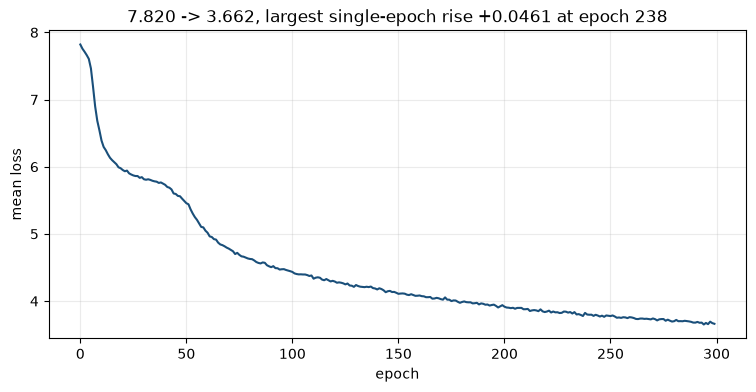

In [6]:
e = np.array(epoch_losses)
rises = np.diff(e)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(e, color="#1a4f7a")
ax.set_xlabel("epoch"); ax.set_ylabel("mean loss")
ax.set_title(f"{e[0]:.3f} -> {e[-1]:.3f}, largest single-epoch rise "
             f"{rises.max():+.4f} at epoch {rises.argmax() + 1}")
ax.grid(alpha=0.25)
plt.show()